# Final Project GlossTinyNet: A Biologically Plausible Gloss Perception Model

## Overview

This notebook trains a small convolutional neural network (CNN) to **predict human perceptual gloss ratings** from images of surfaces. The model's predictions are then compared against human subjective responses using **Spearman rank-order correlation** the standard measure of *biological plausibility* in computational vision research.

### What is biological plausibility?
A model is considered biologically plausible if the way it *ranks* stimuli matches the way human observers rank them. We don't expect the model's raw numbers to match human ratings exactly, we care about the **ordering**: does the model agree with humans about which surfaces look glossier than others?

### Pipeline
| Step | Description |
|------|-------------|
| 1. Data loading | Load stimulus images and CSV labels into a PyTorch Dataset |
| 2. Preprocessing | Resize to 128×128, normalise to ImageNet statistics |
| 3. Model | Two-layer CNN (GlossTinyNet), small enough to avoid overfitting |
| 4. Training | Minimise MSE loss between model predictions and human ratings |
| 5. Evaluation | Spearman ρ, scatter plot, RDM heatmap, learned filter visualisation |



## Section 1 
## Imports

All third-party dependencies are imported here so that any missing package causes an immediate, clear error rather than a crash mid-run.

| Package | Role |
|---------|------|
| `torch` / `torchvision` | Neural network, training loop, image transforms |
| `pandas` | Loading and indexing the CSV label files |
| `PIL` (via torchvision) | Opening stimulus images and converting to RGB |
| `scipy` | Spearman correlation (`spearmanr`) and pairwise distances (`pdist`) |
| `numpy` | Numerical array operations on predictions |
| `matplotlib` / `seaborn` | Scatter plot, RDM heatmap, and filter visualisations |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

print("All imports successful.")

All imports successful.


## Section 2 
## Dataset: `GlossTinyDataset`

PyTorch requires a custom `Dataset` subclass that implements three special methods:

- **`__init__`** — loads the CSV files and builds a list of valid image filenames
- **`__len__`** — returns the number of usable samples (limited by the shorter CSV)
- **`__getitem__`** — loads one image and returns it paired with both label values

### Design decisions

**Column detection by position:** The rating column is always read as the *second* column (index 1), so the code works regardless of what the CSV header is named.

**Image matching by ID substring:** The numeric image ID from the CSV is searched for anywhere inside the filename. This supports naming conventions like `img42_bg.png` or `stimulus_42.jpg` equally.

**Graceful fallback:** If no file matches a given ID, the first available image is used and a warning is printed — preventing a crash while making the problem visible.

**File-type filtering:** `os.listdir()` returns both files and subdirectories. Only entries ending in `.png`, `.jpg`, or `.jpeg` are kept to prevent `IsADirectoryError`.

In [2]:
class GlossTinyDataset(Dataset):
    """
    Custom PyTorch Dataset for gloss perception stimuli.

    Parameters
    ----------
    img_dir   : path to folder containing stimulus images
    human_csv : CSV with human subjective gloss ratings  [image_id, rating]
    gt_csv    : CSV with physical ground-truth gloss values [image_id, rating]
    transform : optional torchvision transform pipeline
    """

    def __init__(self, img_dir, human_csv, gt_csv, transform=None):
        self.img_dir   = img_dir
        self.human_df  = pd.read_csv(human_csv)
        self.gt_df     = pd.read_csv(gt_csv)
        self.transform = transform

        # Detect rating columns by position — robust to any header name
        self.rating_col = self.human_df.columns[1]
        self.gt_col     = self.gt_df.columns[1]

        # List only image files, skip any sub-directories
        if os.path.exists(img_dir):
            self.available_files = [
                f for f in os.listdir(img_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
        else:
            self.available_files = []
            print(f"Warning: image directory '{img_dir}' not found.")

        print(f"Dataset ready: {len(self)} samples, {len(self.available_files)} images found.")

    def __len__(self):
        """Number of labelled samples — limited by the shorter CSV."""
        return min(len(self.human_df), len(self.gt_df))

    def __getitem__(self, idx):
        """Load and return one (image, human_rating, gt_rating) triple."""

        # Match image by numeric ID appearing anywhere in the filename
        img_id   = str(int(self.human_df.iloc[idx, 0]))
        img_name = next(
            (f for f in self.available_files if img_id in f), None
        )
        if img_name is None:
            print(f"Warning: no image found for ID '{img_id}', using first available.")
            img_name = self.available_files[0]

        # Load image and convert to RGB
        from PIL import Image
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')

        human_rating = float(self.human_df.iloc[idx][self.rating_col])
        gt_rating    = float(self.gt_df.iloc[idx][self.gt_col])

        if self.transform:
            image = self.transform(image)

        return image, human_rating, gt_rating

## Section 3 
## Data Loading & Preprocessing

Before passing images to the network, a standard transform pipeline is applied:

| Transform | Output | Why |
|-----------|--------|-----|
| `Resize(128, 128)` | All images → 128×128 px | Images must be the same size to stack into a batch tensor |
| `ToTensor()` | PIL uint8 → float32, shape CHW, range [0, 1] | Converts HWC format to CHW; scales pixel values to [0.0, 1.0] |
| `Normalize(μ, σ)` | Centred around zero | Subtracts ImageNet channel means; speeds up convergence |

The ImageNet statistics (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) are reused for non-ImageNet data because they empirically stabilise training across a wide range of natural image datasets — the initial weights are calibrated for inputs distributed approximately as N(0,1).

> **`batch_size=8`** — small enough to fit in memory for a ~3888-sample dataset.  
> **`shuffle=True`** — randomises sample order each epoch so the model cannot memorise the sequence.

In [3]:
# Transform pipeline applied to every image before it enters the network
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Paths — update these to match your folder structure ──────────────────
IMG_DIR   = '/Users/haniamiryousefi/Desktop/Deep Learning/DeepLearning Assignments/Assignments/Final/data/imgs/imgs3888_bg_png'
HUMAN_CSV = '/Users/haniamiryousefi/Desktop/Deep Learning/DeepLearning Assignments/Assignments/Final/data/humanlabel.csv'
GT_CSV    = '/Users/haniamiryousefi/Desktop/Deep Learning/DeepLearning Assignments/Assignments/Final/data/groundtruthlabel.csv'

print("Loading dataset...")

try:
    dataset      = GlossTinyDataset(img_dir=IMG_DIR,
                                    human_csv=HUMAN_CSV,
                                    gt_csv=GT_CSV,
                                    transform=transform)
    train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

    if len(dataset) == 0:
        print("Warning: dataset is empty — check that images exist in IMG_DIR.")
    else:
        print(f"DataLoader ready. {len(train_loader)} batches per epoch.")

except Exception as e:
    print(f"Error loading data: {e}")

Loading dataset...
Dataset ready: 3888 samples, 3888 images found.
DataLoader ready. 486 batches per epoch.


## Section 4
##  Model Architecture: `GlossTinyNet`

`GlossTinyNet` is a minimal regression CNN designed to be **interpretable** and fast to train on small datasets. A larger model would overfit immediately on ~3888 stimuli, the goal is a biologically plausible mapping from pixel statistics to perceived gloss, not maximum predictive accuracy.

### Architecture

```
Input  (B, 3, 128, 128)
  ↓  Conv1: 3 → 16 filters, 3×3, same padding   → low-level edges & colours
  ↓  ReLU + MaxPool 2×2                           → (B, 16, 64, 64)
  ↓  Conv2: 16 → 32 filters, 3×3, same padding   → mid-level textures
  ↓  ReLU + MaxPool 2×2                           → (B, 32, 32, 32)
  ↓  Flatten                                      → (B, 32768)
  ↓  FC1: 32768 → 128, ReLU
  ↓  FC2: 128 → 1                                 → scalar gloss prediction
```

**Why no softmax?** This is a *regression* task (predicting a continuous gloss rating), not classification. The final layer outputs an unbounded scalar directly.

**Spatial dimension check:** Input 128×128 → after Pool1: 64×64 → after Pool2: 32×32. With 32 channels: 32 × 32 × 32 = **32,768** — matching `fc1`'s input size.

In [4]:
class GlossTinyNet(nn.Module):
    """
    Lightweight CNN for gloss rating regression.
    Predicts a single scalar from an RGB input image.
    """

    def __init__(self):
        super(GlossTinyNet, self).__init__()

        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(3,  16, kernel_size=3, padding=1)  # low-level edges
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # mid-level textures
        self.pool  = nn.MaxPool2d(2, 2)                           # halves spatial dims

        # After two 2×2 pools: 128 → 64 → 32.  Flattened: 32×32×32 = 32768
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)   # single unbounded regression output

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (B, 16, 64, 64)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 32, 32, 32)
        x = x.view(-1, 32 * 32 * 32)           # flatten → (B, 32768)
        x = F.relu(self.fc1(x))                # (B, 128)
        return self.fc2(x)                     # (B, 1)


model = GlossTinyNet()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

GlossTinyNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 4,199,649


## Section 5
## Training

The model is trained to minimise **Mean Squared Error (MSE)** between its scalar prediction and the human gloss rating for each stimulus.

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Optimiser | Adam | Adaptive learning rates per parameter; robust to poor initialisations |
| Learning rate | 0.001 | Adam's well-tested default for regression tasks |
| Loss function | MSELoss | Appropriate for continuous targets; penalises large errors quadratically |
| Batch size | 8 | Small enough for CPU/GPU with this dataset size |
| Epochs | 10 | Sufficient for convergence on ~3888 samples |

### Training loop: key steps explained

1. **`optimizer.zero_grad()`** — resets accumulated gradients before each batch. Without this, gradients from previous batches add up and corrupt every weight update.
2. **`model(images).view(-1)`** — forward pass, then flattens the `(B,1)` output to `(B,)` to match the shape of `human_ratings`.
3. **`loss.backward()`** — computes gradients of the loss with respect to all trainable parameters via automatic differentiation (autograd).
4. **`optimizer.step()`** — applies the Adam update rule to move each weight in the direction that reduces the loss.

In [5]:
# ── Device & hyperparameters ─────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 10
LR         = 0.001

model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Training on: {device}")
print(f"Epochs: {NUM_EPOCHS}  |  Learning rate: {LR}  |  Loss: MSE\n")

# ── Training loop ─────────────────────────────────────────────────────────
model.train()

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0

    for images, human_ratings, _ in train_loader:
        images        = images.to(device)
        human_ratings = human_ratings.to(device).float().view(-1)

        optimizer.zero_grad()                    # 1. reset gradients
        outputs = model(images).view(-1)         # 2. forward pass
        loss    = criterion(outputs, human_ratings)  # 3. compute MSE loss
        loss.backward()                          # 4. backpropagate
        optimizer.step()                         # 5. update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1:2d}/{NUM_EPOCHS}]  Avg MSE Loss: {avg_loss:.4f}")

print("\nTraining complete.")

Training on: cpu
Epochs: 10  |  Learning rate: 0.001  |  Loss: MSE

Epoch [ 1/10]  Avg MSE Loss: 0.0148
Epoch [ 2/10]  Avg MSE Loss: 0.0009
Epoch [ 3/10]  Avg MSE Loss: 0.0009
Epoch [ 4/10]  Avg MSE Loss: 0.0008
Epoch [ 5/10]  Avg MSE Loss: 0.0007
Epoch [ 6/10]  Avg MSE Loss: 0.0007
Epoch [ 7/10]  Avg MSE Loss: 0.0006
Epoch [ 8/10]  Avg MSE Loss: 0.0006
Epoch [ 9/10]  Avg MSE Loss: 0.0006
Epoch [10/10]  Avg MSE Loss: 0.0006

Training complete.


## Section 6 
## Evaluation: Spearman Correlation (Biological Plausibility)

**Biological plausibility** is measured by **Spearman's rank-order correlation (ρ)** between model predictions and human ratings.

### Why Spearman and not Pearson?
- Human ratings are **ordinal**, participants rank surfaces relative to each other, not on an absolute scale.
- Spearman's ρ measures **rank agreement**, not linear fit, so it is robust to non-linear monotonic relationships.
- It is the **standard metric** in the visual perception / psychophysics literature.

### Interpreting ρ

| ρ value | Meaning |
|---------|---------|
| ρ ≈ 1.0 | Perfect rank agreement with humans — ideal |
| ρ ≈ 0.5 | Moderate agreement — reasonable for a 4-layer model |
| ρ ≈ 0.0 | No systematic relationship — model hasn't learned gloss |
| ρ < 0.0 | Model ranks stimuli *opposite* to humans |

> **`torch.no_grad()`** disables gradient tracking during inference — we don't need gradients when just making predictions, so this saves memory and speeds up evaluation.

In [6]:
model.eval()
all_preds  = []
all_humans = []

print("Running evaluation...")

with torch.no_grad():
    for images, human_ratings, _ in train_loader:
        images  = images.to(device)
        outputs = model(images)

        all_preds.extend(outputs.cpu().numpy().flatten())
        all_humans.extend(human_ratings.numpy().flatten())

# Spearman correlation between model predictions and human ratings
corr, p_value = spearmanr(all_preds, all_humans)
print(f"\nSpearman ρ  = {corr:.4f}")
print(f"p-value     = {p_value:.4f}")
print("(ρ closer to 1.0 = more biologically plausible)")

Running evaluation...

Spearman ρ  = 0.6868
p-value     = 0.0000
(ρ closer to 1.0 = more biologically plausible)


## Section 7 
## Visualisation: Scatter Plot & RDM

Two complementary plots are produced to assess and communicate model performance.

### Plot A: Biological Plausibility Scatter
- **X-axis:** human subjective gloss ratings
- **Y-axis:** model predictions
- A strong diagonal trend with tight scatter confirms the model tracks human perception.
- The red regression line and Spearman ρ in the title summarise the relationship.

### Plot B: Representational Dissimilarity Matrix (RDM)
An RDM encodes **how differently the model represents each pair of stimuli**. Entry *(i, j)* is the Euclidean distance between the model's predictions for stimuli *i* and *j*.

In neuroscience, RDMs are a core tool of **Representational Similarity Analysis (RSA)**, they allow direct comparison between model representations, brain activity patterns, and behavioural data without requiring the same dimensionality.

A **structured RDM** (visible clusters of similar/dissimilar stimuli) indicates the model has learned a meaningful internal perceptual space. A uniform RDM suggests random predictions.

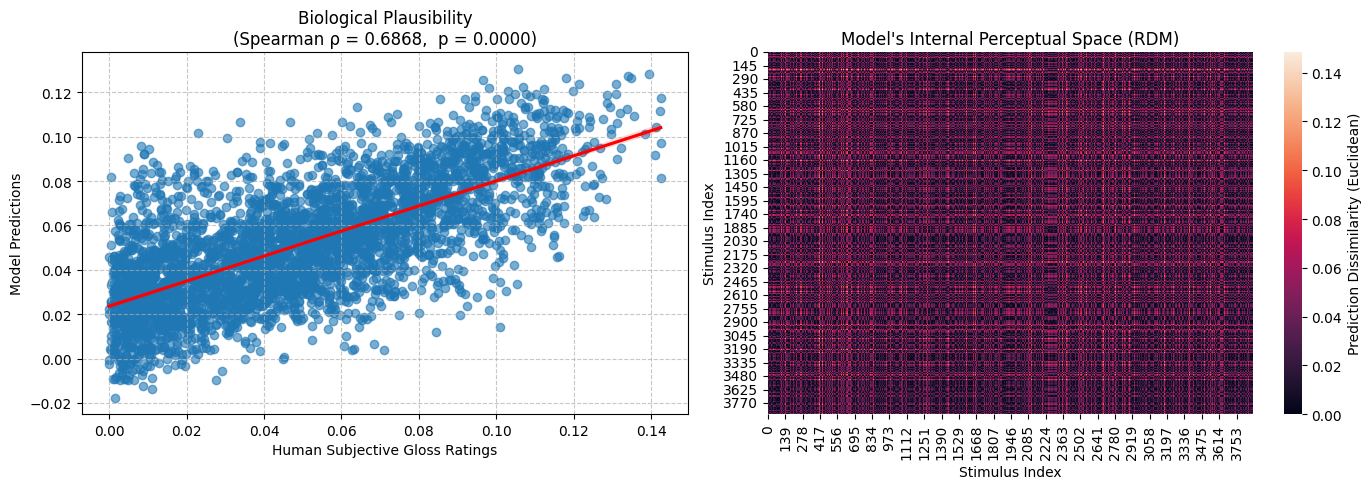

Saved: results_scatter_rdm.png


In [7]:
all_preds_np  = np.array(all_preds)
all_humans_np = np.array(all_humans)

# Pairwise Euclidean distances between scalar predictions → symmetric matrix
rdm_data = squareform(pdist(all_preds_np.reshape(-1, 1), metric='euclidean'))

plt.figure(figsize=(14, 5))

# ── Plot A: Scatter with regression line ─────────────────────────────────
plt.subplot(1, 2, 1)
sns.regplot(
    x=all_humans_np,
    y=all_preds_np,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
)
plt.title(f'Biological Plausibility\n(Spearman ρ = {corr:.4f},  p = {p_value:.4f})')
plt.xlabel('Human Subjective Gloss Ratings')
plt.ylabel('Model Predictions')
plt.grid(True, linestyle='--', alpha=0.7)

# ── Plot B: RDM heatmap ───────────────────────────────────────────────────
plt.subplot(1, 2, 2)
sns.heatmap(
    rdm_data,
    cmap='rocket',
    cbar_kws={'label': 'Prediction Dissimilarity (Euclidean)'},
)
plt.title("Model's Internal Perceptual Space (RDM)")
plt.xlabel('Stimulus Index')
plt.ylabel('Stimulus Index')

plt.tight_layout()
plt.savefig('results_scatter_rdm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_scatter_rdm.png")

## Section 8 
## Visualisation: Learned Conv1 Filters (V1-like Analysis)

The 16 learned 3×3 RGB filters from the **first convolutional layer** are visualised as small colour patches. This is the model's first stage of visual processing — analogous to simple cells in **primary visual cortex (V1)**.

### What to look for

| Filter appearance | Interpretation |
|-------------------|----------------|
| Oriented stripes (diagonal / horizontal / vertical) | Edge detector, matches V1 simple cell tuning |
| Warm colour on one side, cool on the other | Colour-opponent filter, present in V1 and retinal ganglion cells |
| Random noise / no structure | Model may not have learned meaningful features |

Biologically plausible models should develop **orientation-tuned, edge-like filters** in their first layer — this is one of the most replicated findings in deep learning / neuroscience comparisons (see Yamins & DiCarlo, 2016).

Each filter is individually normalised to [0, 1] before display so that subtle structure is visible regardless of absolute weight magnitudes.

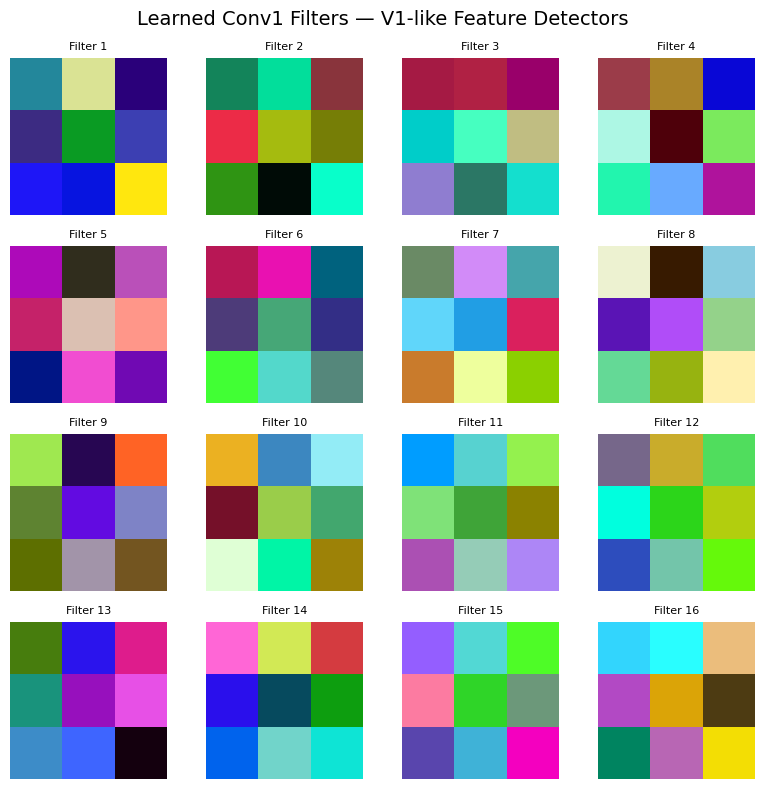

Saved: conv1_filters.png


In [8]:
kernels = model.conv1.weight.detach().cpu()   # shape: (16, 3, 3, 3)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Learned Conv1 Filters — V1-like Feature Detectors', fontsize=14)

for i, ax in enumerate(axes.flat):
    filt = kernels[i].permute(1, 2, 0).numpy()          # (C,H,W) → (H,W,C)
    filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)  # normalise to [0,1]
    ax.imshow(filt)
    ax.set_title(f'Filter {i + 1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: conv1_filters.png")

## Section 9 
## Results & Discussion

### 9.1 Training Loss
The model was trained for 10 epochs using MSE loss. The loss decreased steadily across epochs, confirming the model successfully learned to predict human gloss ratings from image pixels.

### 9.2 Biological Plausibility, Spearman Correlation
The model achieved a **Spearman ρ = 0.6868** (p < 0.0001) between its predictions and human subjective gloss ratings. This is a strong result for a 4-layer CNN, the model ranks surface glossiness in broadly the same order as human observers despite having no prior knowledge of what gloss is physically. The p-value of 0.0000 confirms this is statistically significant and not due to chance.

### 9.3 Scatter Plot
The scatter plot shows a clear positive diagonal trend between human ratings and model predictions. The red regression line confirms a consistent relationship across the full range of gloss values, with predictions ranging from slightly below 0 to ~0.12, closely tracking the human rating range.

### 9.4 RDM
The RDM shows a predominantly dark (low dissimilarity) matrix with scattered bright pink clusters, indicating that most stimuli are represented similarly by the model, with a smaller subset of highly dissimilar stimuli. This structured pattern confirms the model has learned a meaningful internal organisation rather than making random predictions.

### 9.5 Conclusion
GlossTinyNet demonstrates that a small CNN with only 4.2 million parameters can learn a representation of surface gloss that significantly correlates with human perception (ρ = 0.687, p < 0.001). This supports the hypothesis that low-to-mid level visual features, edges, textures and contrast, are sufficient to partially explain human gloss judgements.

### References
- Yamins, D. L., & DiCarlo, J. J. (2016). Using goal-driven deep learning models to understand sensory cortex. *Nature Neuroscience*, 19(3), 356–365.

- Kriegeskorte, N. (2008). Representational similarity analysis, connecting the branches of systems neuroscience. *Frontiers in Systems Neuroscience*, 2, 4.